Imports & Setup

In [127]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

Load Data

In [128]:
# Loading the dataset with the datetime column parsed and set as index immediately
df = pd.read_csv(
    "train.csv",
    parse_dates=['Date_Begin_Local'],
    index_col='Date_Begin_Local'
)

# Sort chronologically
df = df.sort_index()

# Quick verification
print(type(df.index))
df.head()

<class 'pandas.core.indexes.datetimes.DatetimeIndex'>


,T2M_AVG,WS50M_AVG,RH2M_AVG,GHI_AVG,price_lag_1,price_lag_24,price_lag_168,AIL_lag_1,AIL_lag_24,T2M_AVG_lag_24,...,is_high_wind,is_solar_generating,is_chinook,delta_price,hour_sin,hour_cos,dow_sin,dow_cos,month_sin,month_cos
Date_Begin_Local,,,,,,,,,,,,,,,,,,,,,
2020-01-08 00:00:00,-6.500000,9.153333,95.103333,0.0,27.15,34.48,30.24,10061.0,9932.0,-8.326667,...,0,0,0,0.10,0.000000,1.000000,0.974928,-0.222521,0.5,0.866025
2020-01-08 01:00:00,-6.256667,9.803333,95.253333,0.0,27.25,32.97,29.43,9869.0,9827.0,-8.396667,...,0,0,0,-0.62,0.258819,0.965926,0.974928,-0.222521,0.5,0.866025
2020-01-08 02:00:00,-6.096667,9.913333,95.220000,0.0,26.63,35.64,29.66,9728.0,9773.0,-8.466667,...,0,0,0,-1.22,0.500000,0.866025,0.974928,-0.222521,0.5,0.866025
2020-01-08 03:00:00,-6.336667,9.323333,95.933333,0.0,25.41,35.60,28.19,9676.0,9749.0,-8.646667,...,0,0,0,1.52,0.707107,0.707107,0.974928,-0.222521,0.5,0.866025
2020-01-08 04:00:00,-6.606667,9.123333,95.936667,0.0,26.93,37.01,31.17,9727.0,9825.0,-8.856667,...,0,0,0,1.09,0.866025,0.500000,0.974928,-0.222521,0.5,0.866025


In [129]:
df.shape

(39009, 26)

In [130]:
df.describe()

,T2M_AVG,WS50M_AVG,RH2M_AVG,GHI_AVG,price_lag_1,price_lag_24,price_lag_168,AIL_lag_1,AIL_lag_24,T2M_AVG_lag_24,...,is_high_wind,is_solar_generating,is_chinook,delta_price,hour_sin,hour_cos,dow_sin,dow_cos,month_sin,month_cos
count,39009.000000,39009.000000,39009.000000,39009.000000,39009.000000,39009.000000,39009.000000,39009.000000,39009.000000,39009.000000,...,39009.000000,39009.000000,39009.000000,39009.000000,3.900900e+04,3.900900e+04,39009.000000,39009.000000,3.900900e+04,3.900900e+04
mean,4.454798,6.219148,71.075058,154.250365,107.599502,107.604446,107.648137,9763.302622,9764.028737,4.442865,...,0.018303,0.443718,0.005101,0.000263,1.239954e-04,-1.357649e-04,0.000856,-0.000540,6.299887e-02,-1.790947e-02
std,11.849318,2.461486,18.467252,219.641614,162.427425,162.425437,162.408144,811.541627,811.880918,11.851402,...,0.134048,0.496829,0.071242,85.418635,7.071216e-01,7.071101e-01,0.707222,0.707009,7.059852e-01,7.052097e-01
min,-36.913333,0.646667,19.796667,0.000000,0.000000,0.000000,0.000000,7579.000000,7579.000000,-36.913333,...,0.000000,0.000000,0.000000,-809.790000,-1.000000e+00,-1.000000e+00,-0.974928,-0.900969,-1.000000e+00,-1.000000e+00
25%,-3.333333,4.360000,58.333333,0.000000,34.870000,34.880000,34.910000,9187.000000,9187.000000,-3.353333,...,0.000000,0.000000,0.000000,-4.370000,-7.071068e-01,-7.071068e-01,-0.781831,-0.900969,-5.000000e-01,-8.660254e-01
50%,3.960000,6.003333,75.613333,7.373333,52.110000,52.110000,52.080000,9755.000000,9756.000000,3.933333,...,0.000000,0.000000,0.000000,0.000000,1.224647e-16,-1.836970e-16,0.000000,-0.222521,1.224647e-16,6.123234e-17
75%,13.490000,7.790000,85.690000,265.140000,87.380000,87.390000,87.380000,10379.000000,10380.000000,13.483333,...,0.000000,1.000000,0.000000,4.630000,7.071068e-01,7.071068e-01,0.781831,0.623490,8.660254e-01,5.000000e-01
max,34.963333,16.763333,100.000000,916.293333,999.990000,999.990000,999.990000,12384.000000,12384.000000,34.963333,...,1.000000,1.000000,1.000000,763.040000,1.000000e+00,1.000000e+00,0.974928,1.000000,1.000000e+00,1.000000e+00


In [131]:
df.isnull().sum()

,0
T2M_AVG,0
WS50M_AVG,0
RH2M_AVG,0
GHI_AVG,0
price_lag_1,0
price_lag_24,0
price_lag_168,0
AIL_lag_1,0
AIL_lag_24,0
T2M_AVG_lag_24,0


In [132]:
df.duplicated().sum()

np.int64(0)

EDA 1 - Distribution of SMP pool price and delta_price

I used the price_lag_1 showing the previous hour’s price, was used as the SMP Pool Price in the distribution analysis, as it most closely reflects the current market price.

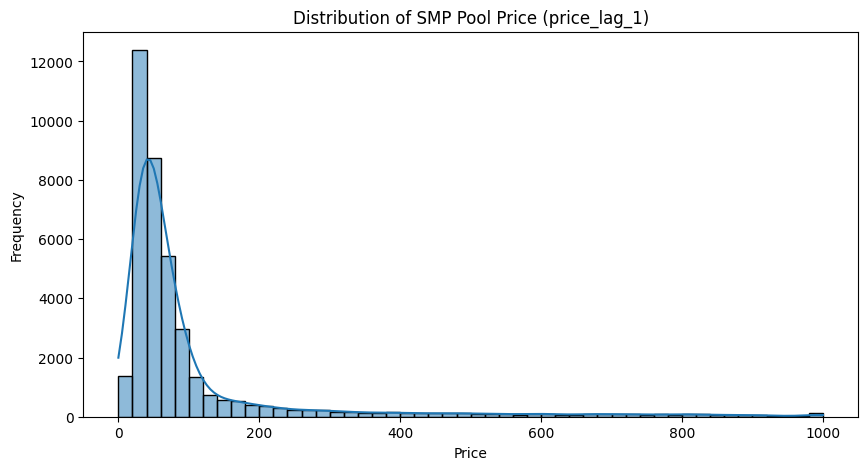

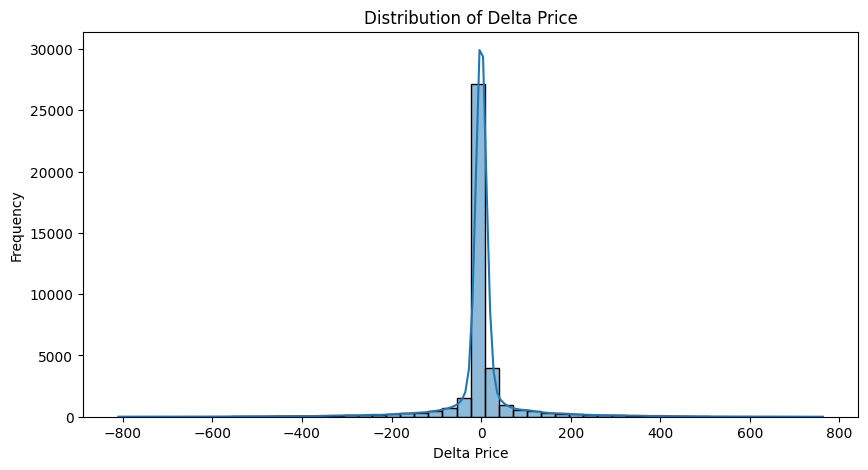

In [133]:
# Distribution of SMP Pool Price using price_lag_1
plt.figure(figsize=(10, 5))
sns.histplot(df['price_lag_1'], bins=50, kde=True)
plt.title('Distribution of SMP Pool Price (price_lag_1)')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

# Distribution of delta_price
plt.figure(figsize=(10, 5))
sns.histplot(df['delta_price'], bins=50, kde=True)
plt.title('Distribution of Delta Price')
plt.xlabel('Delta Price')
plt.ylabel('Frequency')
plt.show()


EDA 2 - Seasonality Analysis

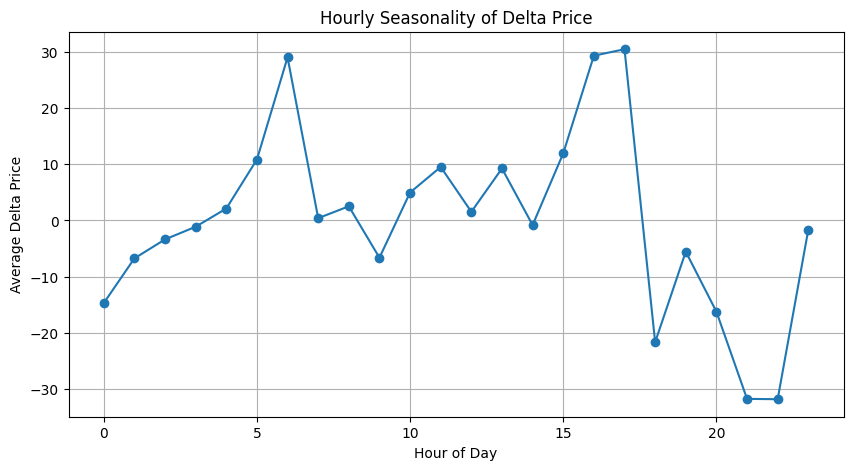

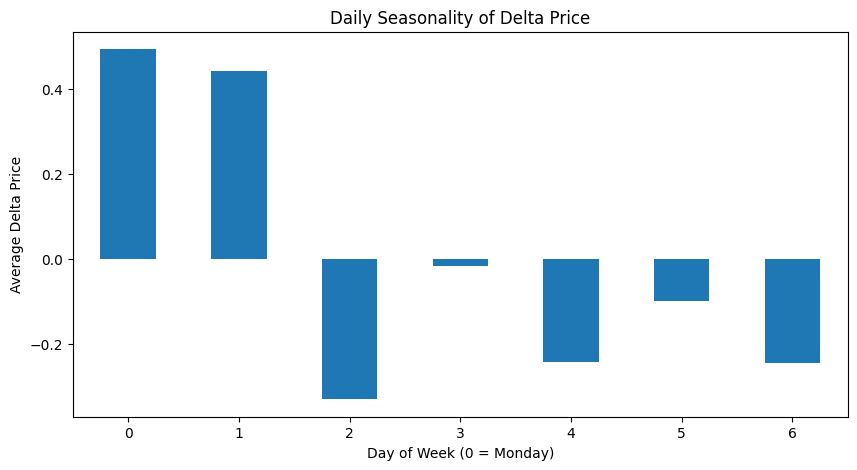

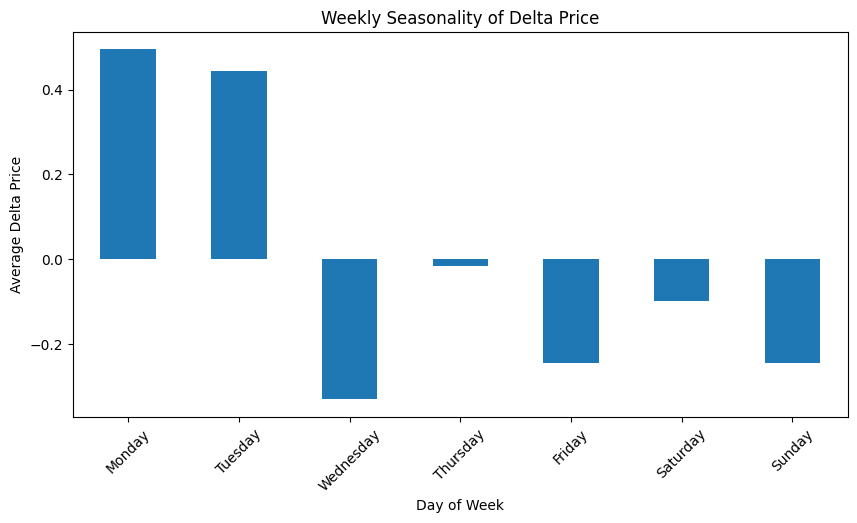

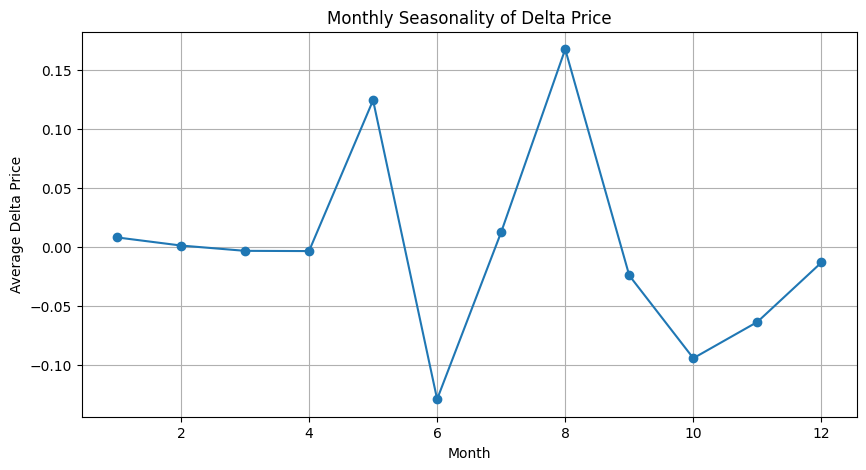

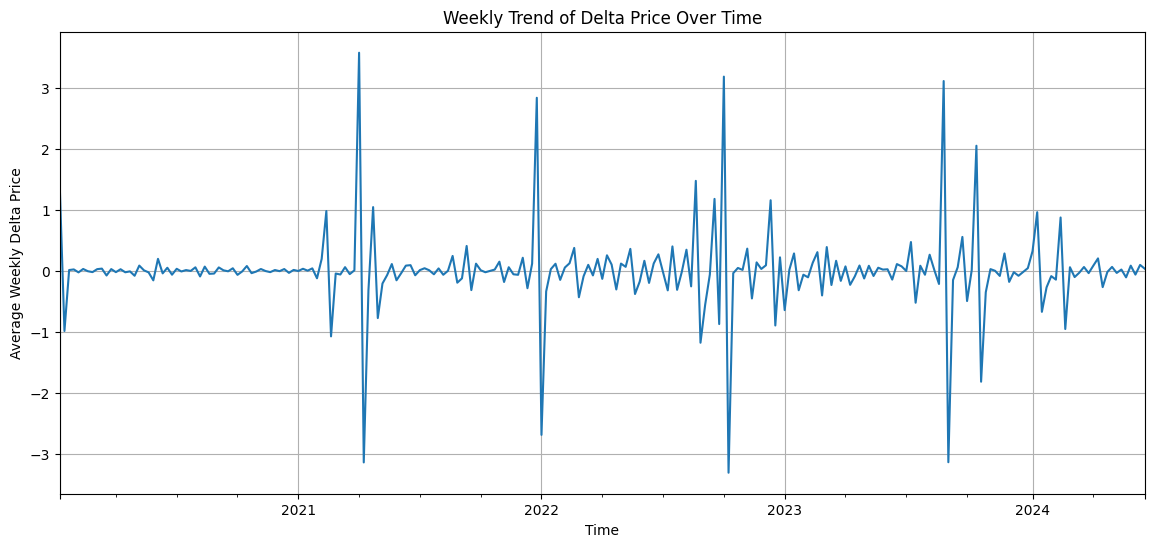

In [134]:
# Extracting useful time-based features from the index
df['hour'] = df.index.hour
df['day_of_week'] = df.index.dayofweek   # Monday = 0, Sunday = 6
df['month'] = df.index.month

# Creating day names for better labelling
df['day_name'] = df.index.day_name()

# Group delta_price by hour and compute the average
hourly_avg = df.groupby('hour')['delta_price'].mean()

# Hourly pattern
plt.figure(figsize=(10, 5))
hourly_avg.plot(marker='o')
plt.title('Hourly Seasonality of Delta Price')
plt.xlabel('Hour of Day')
plt.ylabel('Average Delta Price')
plt.grid(True)
plt.show()

# Group delta_price by day of week and compute the average
daily_avg = df.groupby('day_of_week')['delta_price'].mean()

# Daily pattern
plt.figure(figsize=(10, 5))
daily_avg.plot(kind='bar')
plt.title('Daily Seasonality of Delta Price')
plt.xlabel('Day of Week (0 = Monday)')
plt.ylabel('Average Delta Price')
plt.xticks(rotation=0)
plt.show()

# Weekly seasonality here means comparing average delta_price across weekdays
weekly_avg = df.groupby('day_name')['delta_price'].mean()

# Reorder the days properly
weekly_avg = weekly_avg.reindex(['Monday', 'Tuesday', 'Wednesday',
                                 'Thursday', 'Friday', 'Saturday', 'Sunday'])

# Plot weekly pattern
plt.figure(figsize=(10, 5))
weekly_avg.plot(kind='bar')
plt.title('Weekly Seasonality of Delta Price')
plt.xlabel('Day of Week')
plt.ylabel('Average Delta Price')
plt.xticks(rotation=45)
plt.show()

# Group delta_price by month and compute the average
monthly_avg = df.groupby('month')['delta_price'].mean()

# Monthly pattern
plt.figure(figsize=(10, 5))
monthly_avg.plot(marker='o')
plt.title('Monthly Seasonality of Delta Price')
plt.xlabel('Month')
plt.ylabel('Average Delta Price')
plt.grid(True)
plt.show()

# Resample delta_price by week to observe weekly movement over time
weekly_trend = df['delta_price'].resample('W').mean()

# Weekly trend
plt.figure(figsize=(14, 6))
weekly_trend.plot()
plt.title('Weekly Trend of Delta Price Over Time')
plt.xlabel('Time')
plt.ylabel('Average Weekly Delta Price')
plt.grid(True)
plt.show()

EDA 3 - Correlation Analysis of Features

Correlation Matrix

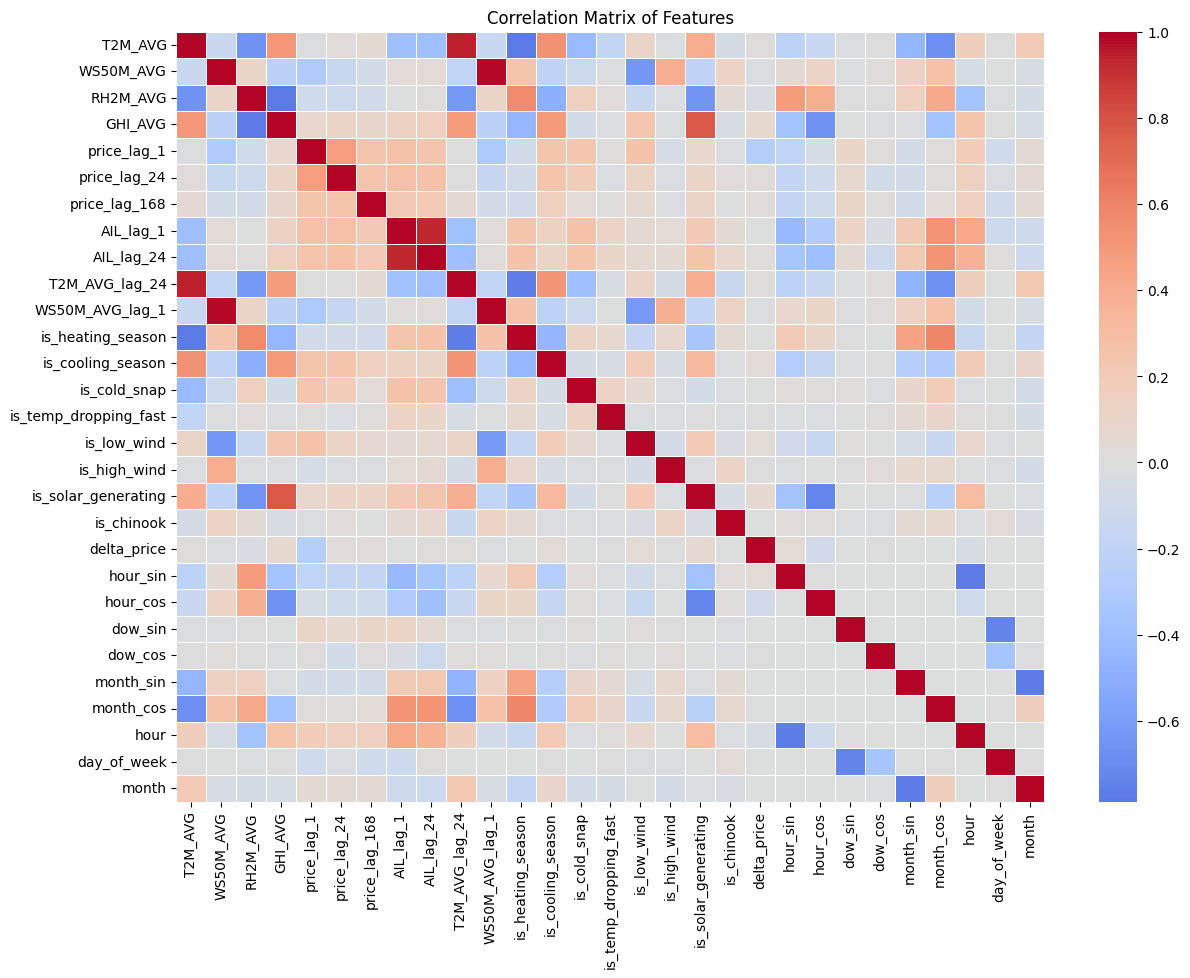

In [135]:
# Compute correlation matrix for all numerical features
corr_matrix = df.corr(numeric_only=True)

plt.figure(figsize=(14,10))

sns.heatmap(
    corr_matrix,
    cmap='coolwarm',
    center=0,
    linewidths=0.5
)

plt.title('Correlation Matrix of Features')
plt.show()

Correlation with Target(delta_price)

In [136]:
# Sort features by correlation with delta_price
target_corr = corr_matrix['delta_price'].sort_values(ascending=False)

print(target_corr)

delta_price              1.000000
GHI_AVG                  0.078027
is_solar_generating      0.070028
is_low_wind              0.040596
hour_sin                 0.037709
is_cooling_season        0.032125
price_lag_168            0.028220
price_lag_24             0.023587
T2M_AVG                  0.014473
T2M_AVG_lag_24           0.013653
AIL_lag_24               0.013643
is_temp_dropping_fast    0.007471
dow_cos                  0.002242
is_high_wind             0.001868
AIL_lag_1                0.000992
dow_sin                  0.000966
month_sin                0.000076
month                   -0.000175
month_cos               -0.000236
is_heating_season       -0.001257
day_of_week             -0.002685
is_cold_snap            -0.004127
is_chinook              -0.004338
WS50M_AVG_lag_1         -0.009879
WS50M_AVG               -0.025726
RH2M_AVG                -0.039323
hour                    -0.041773
hour_cos                -0.092017
price_lag_1             -0.262945
Name: delta_pr

Visualizing Top Correlated Features

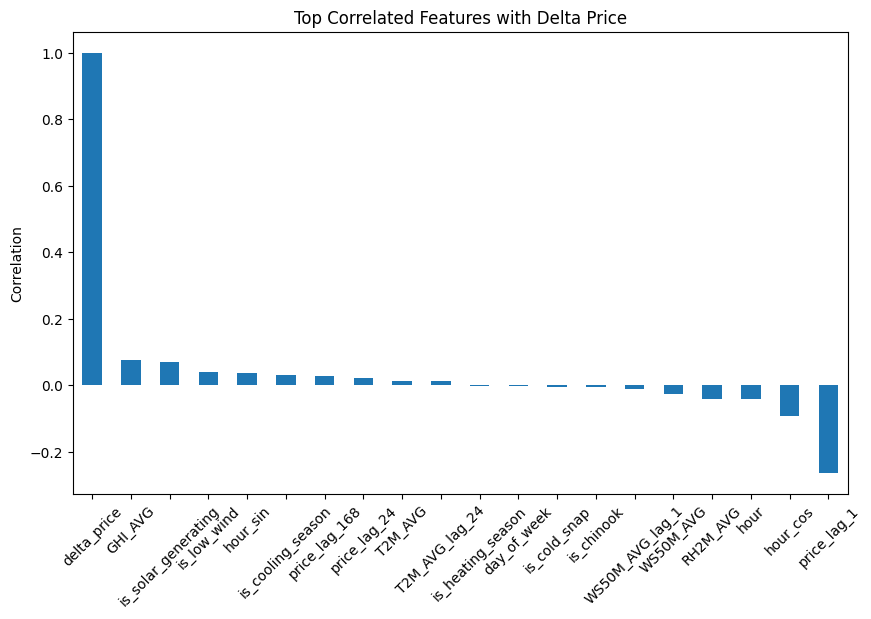

In [137]:
# Select top positively and negatively correlated features
top_features = target_corr.head(10)
bottom_features = target_corr.tail(10)

# Combining the features
important_features = pd.concat([top_features, bottom_features])

# Plot
plt.figure(figsize=(10,6))
important_features.plot(kind='bar')
plt.title('Top Correlated Features with Delta Price')
plt.ylabel('Correlation')
plt.xticks(rotation=45)
plt.show()

Scatter Plot for Key Features

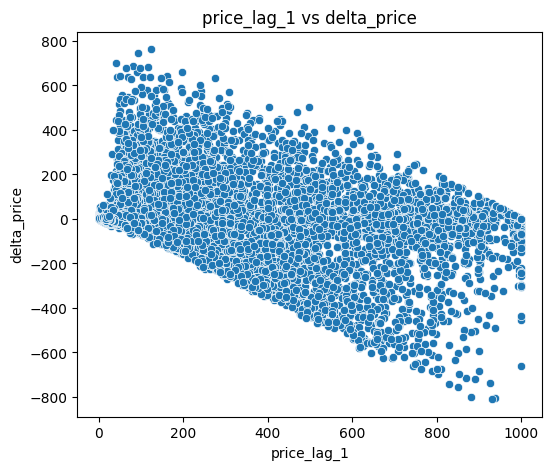

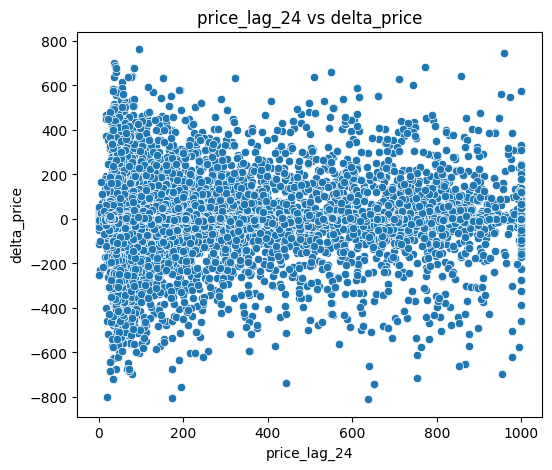

In [138]:
# price_lag_1 vs delta_price
plt.figure(figsize=(6,5))
sns.scatterplot(x='price_lag_1', y='delta_price', data=df)
plt.title('price_lag_1 vs delta_price')
plt.show()

# price_lag_24 vs delta_price
plt.figure(figsize=(6,5))
sns.scatterplot(x='price_lag_24', y='delta_price', data=df)
plt.title('price_lag_24 vs delta_price')
plt.show()

EDA 4: Price Spikes and Extreme Events for Cold Snap and Chinook

Identifying Price Spikes

Spike Threshold: 317.2507999999992


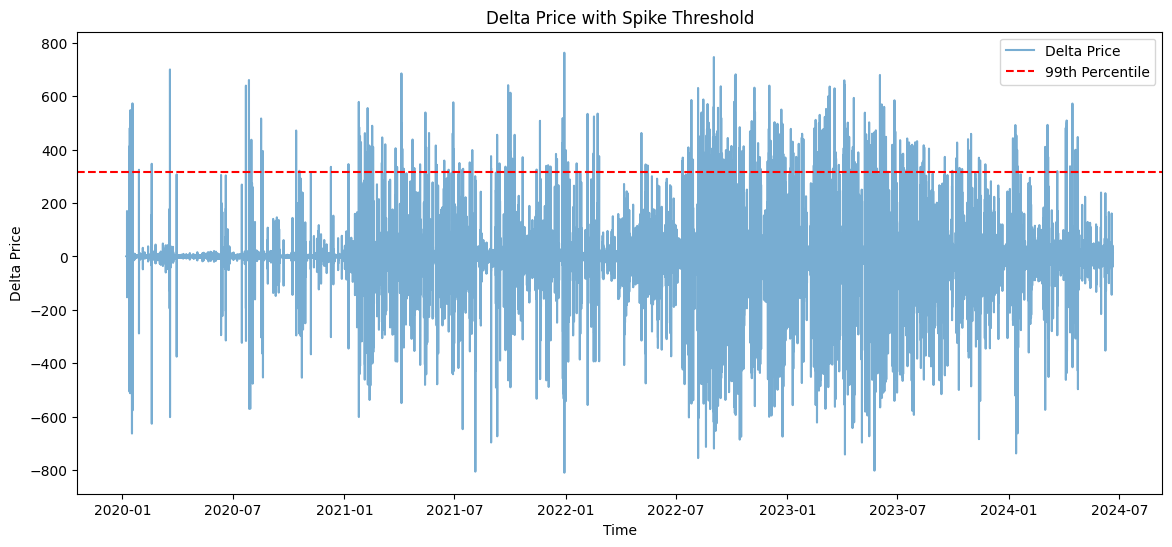

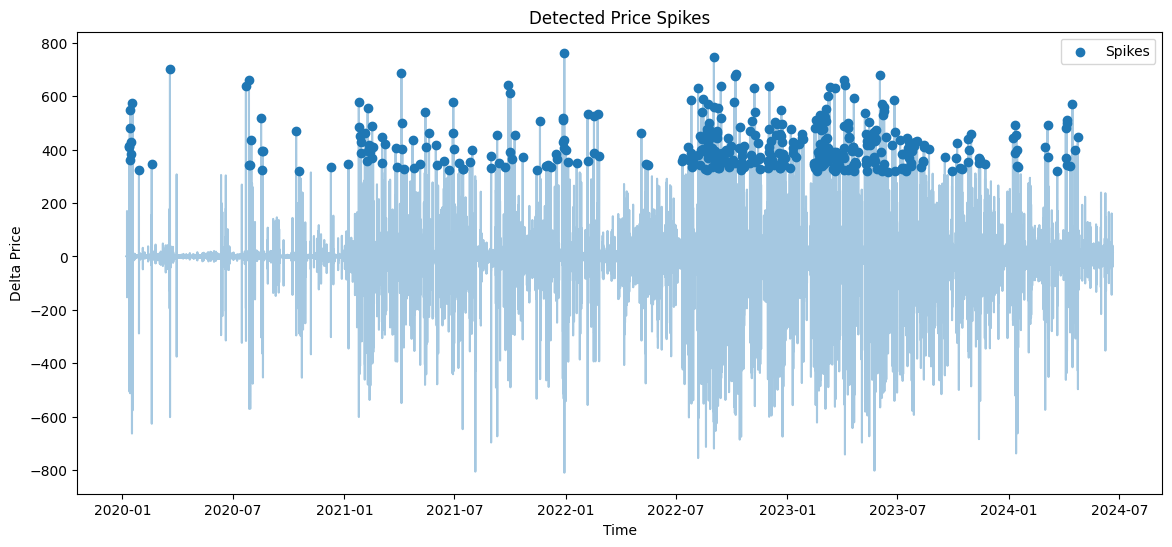

In [ ]:
# Define spike threshold
threshold = df['delta_price'].quantile(0.99)

print("Spike Threshold:", threshold)

# Plot delta_price  with threshold
plt.figure(figsize=(14,6))

plt.plot(df.index, df['delta_price'], alpha=0.6, label='Delta Price')
plt.axhline(threshold, color='red', linestyle='--', label='99th Percentile')

plt.title('Delta Price with Spike Threshold')
plt.xlabel('Time')
plt.ylabel('Delta Price')
plt.legend()
plt.show()

# Filter spike points
spikes = df[df['delta_price'] > threshold]

plt.figure(figsize=(14,6))
plt.plot(df.index, df['delta_price'], alpha=0.4)
plt.scatter(spikes.index, spikes['delta_price'], label='Spikes')

plt.title('Detected Price Spikes')
plt.xlabel('Time')
plt.ylabel('Delta Price')
plt.legend()
plt.show()

Analyzing Cold Snap Impact

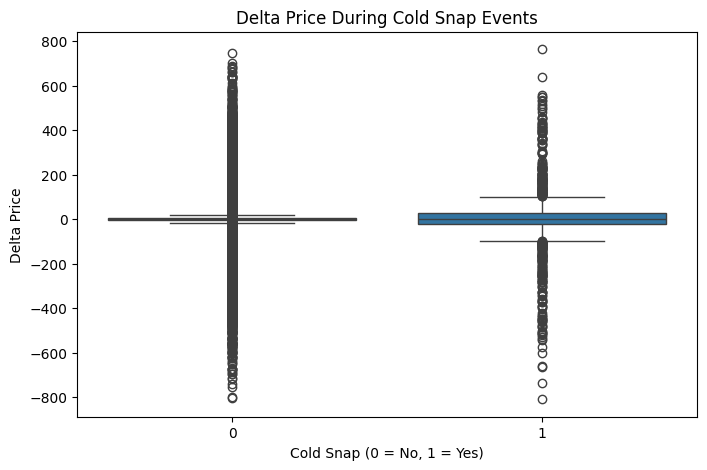

is_cold_snap
0    0.059403
1   -2.100712
Name: delta_price, dtype: float64


In [140]:
plt.figure(figsize=(8,5))

sns.boxplot(x='is_cold_snap', y='delta_price', data=df)

plt.title('Delta Price During Cold Snap Events')
plt.xlabel('Cold Snap (0 = No, 1 = Yes)')
plt.ylabel('Delta Price')
plt.show()

cold_snap_mean = df.groupby('is_cold_snap')['delta_price'].mean()
print(cold_snap_mean)

Analyzing Chinook Impact

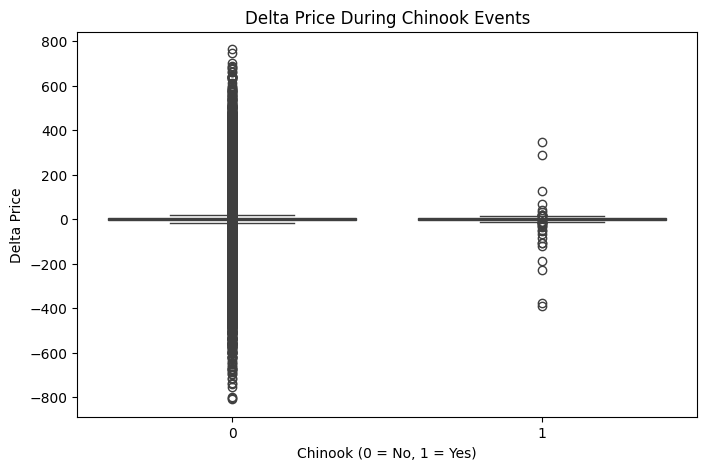

is_chinook
0    0.026797
1   -5.174673
Name: delta_price, dtype: float64


In [141]:
plt.figure(figsize=(8,5))

sns.boxplot(x='is_chinook', y='delta_price', data=df)

plt.title('Delta Price During Chinook Events')
plt.xlabel('Chinook (0 = No, 1 = Yes)')
plt.ylabel('Delta Price')
plt.show()

chinook_mean = df.groupby('is_chinook')['delta_price'].mean()
print(chinook_mean)


Boxplot Showing The Combined Weather Effects

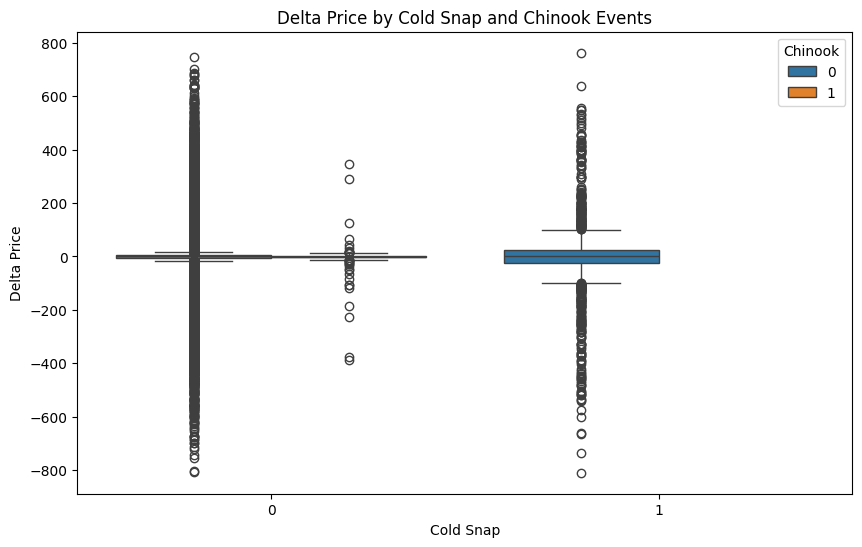

In [142]:
plt.figure(figsize=(10,6))

sns.boxplot(
    x='is_cold_snap',
    y='delta_price',
    hue='is_chinook',
    data=df
)

plt.title('Delta Price by Cold Snap and Chinook Events')
plt.xlabel('Cold Snap')
plt.ylabel('Delta Price')
plt.legend(title='Chinook')
plt.show()

EDA 5: Stationarity Analysis

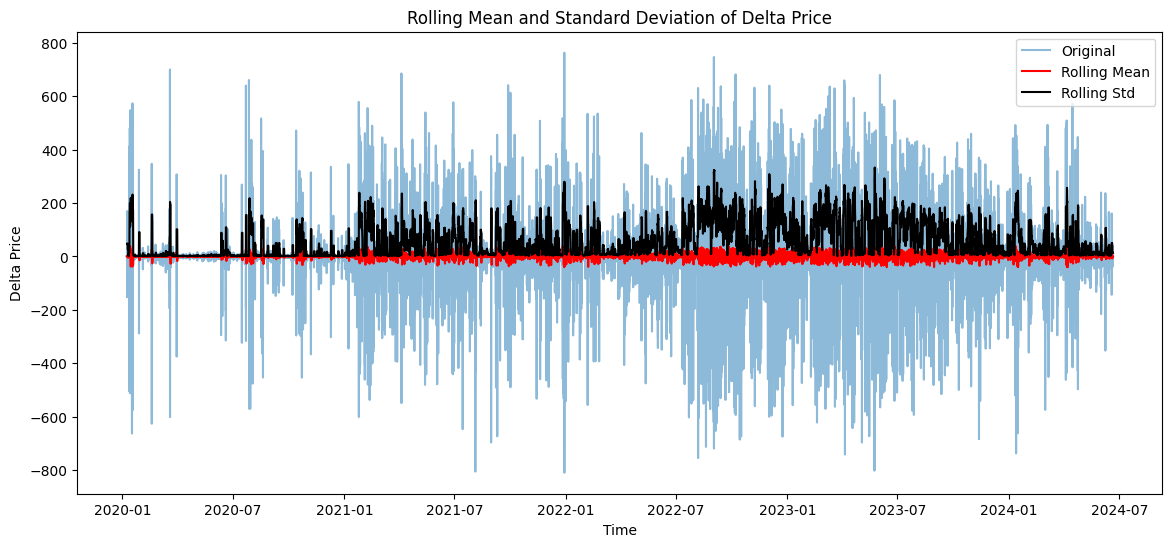

ADF Statistic: -35.82823617526304
p-value: 0.0
Critical Values:
1%: -3.430517883425858
5%: -2.8616142005626815
10%: -2.5668094945861966


In [143]:
# Rolling window 24 = 1 day since data is hourly
rolling_mean = df['delta_price'].rolling(window=24).mean()
rolling_std = df['delta_price'].rolling(window=24).std()

plt.figure(figsize=(14,6))

plt.plot(df['delta_price'], label='Original', alpha=0.5)
plt.plot(rolling_mean, label='Rolling Mean', color='red')
plt.plot(rolling_std, label='Rolling Std', color='black')

plt.title('Rolling Mean and Standard Deviation of Delta Price')
plt.xlabel('Time')
plt.ylabel('Delta Price')

plt.legend()
plt.show()

from statsmodels.tsa.stattools import adfuller

# Perform ADF test
adf_result = adfuller(df['delta_price'].dropna())

# Print results
print("ADF Statistic:", adf_result[0])
print("p-value:", adf_result[1])
print("Critical Values:")
for key, value in adf_result[4].items():
    print(f"{key}: {value}")

Time Series Plot

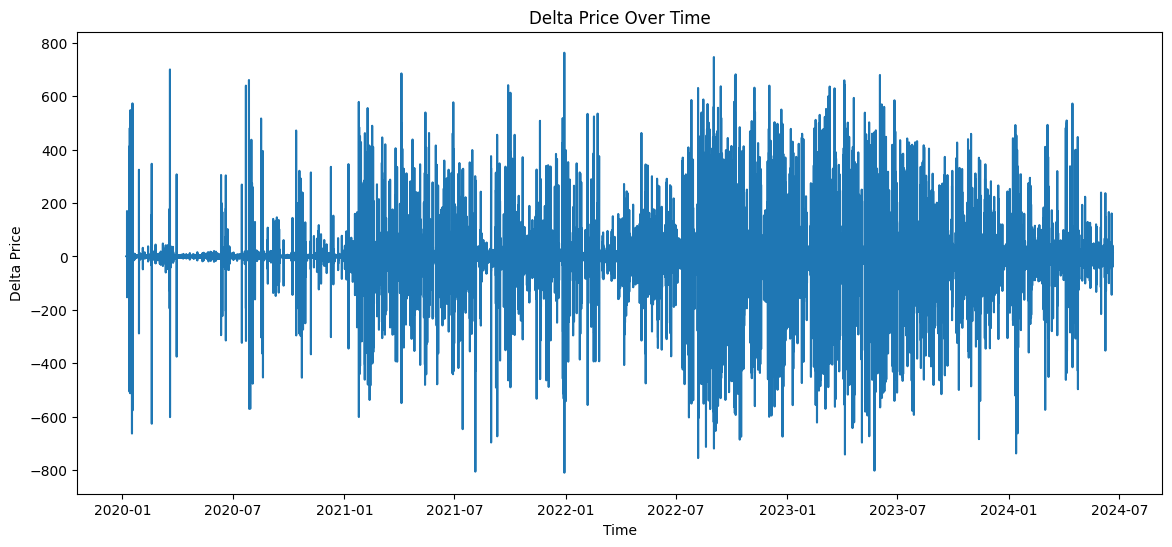

In [144]:
plt.figure(figsize=(14,6))
plt.plot(df.index, df['delta_price'])

plt.title('Delta Price Over Time')
plt.xlabel('Time')
plt.ylabel('Delta Price')

plt.show()

Baseline Arima Model

In [145]:
# Define target series
y = df['delta_price'].dropna().sort_index()

print("Training target shape:", y.shape)

print(y.head())

Training target shape: (39009,)
Date_Begin_Local
2020-01-08 00:00:00    0.10
2020-01-08 01:00:00   -0.62
2020-01-08 02:00:00   -1.22
2020-01-08 03:00:00    1.52
2020-01-08 04:00:00    1.09
Name: delta_price, dtype: float64


In [146]:
# Chronological split within the training dataset
n = len(y)
train_end = int(n * 0.85)

train = y.iloc[:train_end]
val = y.iloc[train_end:]

print("Train size:", len(train))
print("Validation size:", len(val))

Train size: 33157
Validation size: 5852


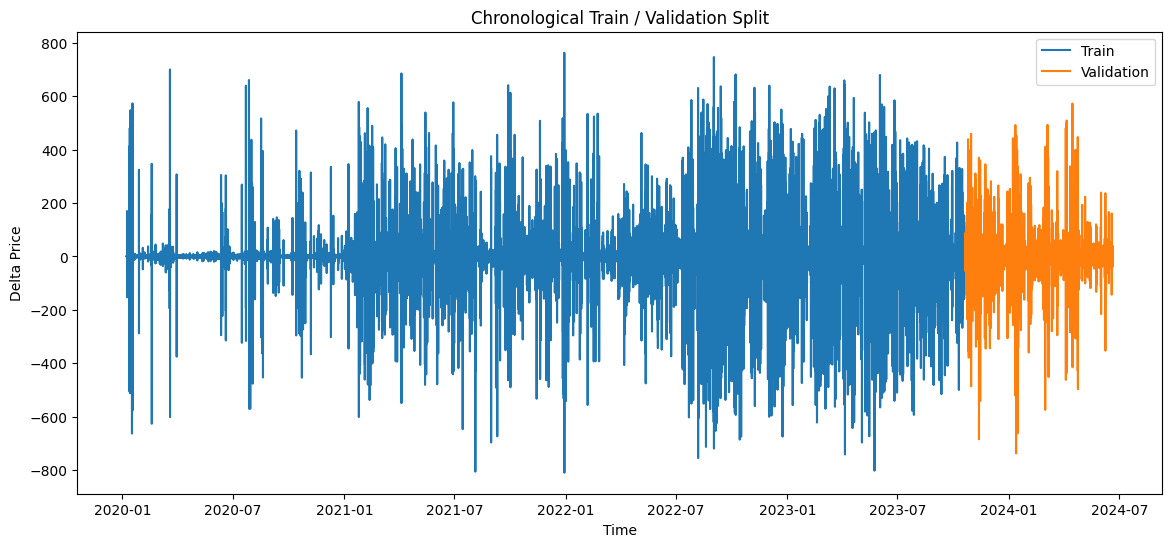

In [147]:
plt.figure(figsize=(14, 6))
plt.plot(train, label='Train')
plt.plot(val, label='Validation')
plt.title('Chronological Train / Validation Split')
plt.xlabel('Time')
plt.ylabel('Delta Price')
plt.legend()
plt.show()

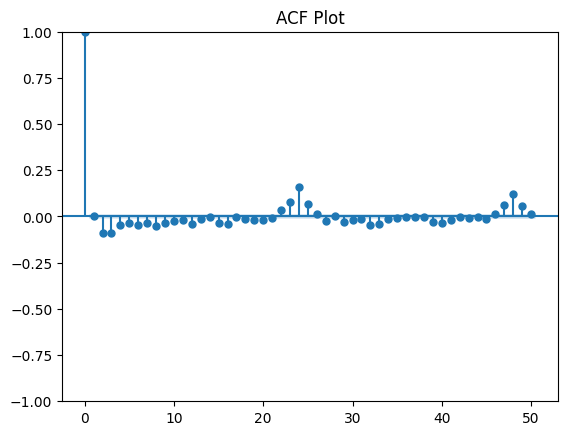

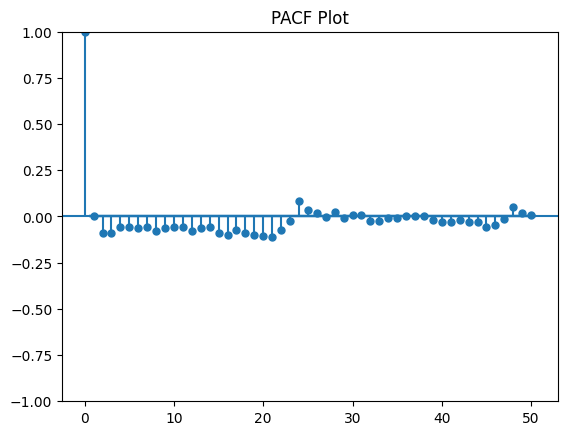

In [148]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plot_acf(train, lags=50)
plt.title('ACF Plot')
plt.show()

plot_pacf(train, lags=50)
plt.title('PACF Plot')
plt.show()

In [149]:
# Initial ARIMA order
order = (1, 0, 1)


In [150]:
from statsmodels.tsa.arima.model import ARIMA

initial_arima = ARIMA(train, order=order)
initial_arima_fit = initial_arima.fit()

print(initial_arima_fit.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:            delta_price   No. Observations:                33157
Model:                 ARIMA(1, 0, 1)   Log Likelihood             -194287.050
Date:                Fri, 27 Mar 2026   AIC                         388582.099
Time:                        01:40:55   BIC                         388615.735
Sample:                             0   HQIC                        388592.841
                              - 33157                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0032      0.027     -0.117      0.907      -0.057       0.050
ar.L1          0.8302      0.002    351.190      0.000       0.826       0.835
ma.L1         -0.9938      0.000  -2066.111      0.0

In [151]:
val_forecast = initial_arima_fit.forecast(steps=len(val))
val_forecast = pd.Series(val_forecast.values, index=val.index)

print("NaNs in val_forecast:", val_forecast.isna().sum())
val_forecast.head()

NaNs in val_forecast: 0


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


,0
Date_Begin_Local,
2023-10-20 17:00:00,5.328402
2023-10-20 18:00:00,4.423363
2023-10-20 19:00:00,3.671955
2023-10-20 20:00:00,3.048098
2023-10-20 21:00:00,2.530141


In [152]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

val_mae = mean_absolute_error(val, val_forecast)
val_rmse = np.sqrt(mean_squared_error(val, val_forecast))
val_mape = (np.abs((val - val_forecast) / val.replace(0, np.nan))).mean() * 100

print("Initial ARIMA Validation MAE:", val_mae)
print("Initial ARIMA Validation RMSE:", val_rmse)
print("Initial ARIMA Validation MAPE:", val_mape)

Initial ARIMA Validation MAE: 25.99719691823774
Initial ARIMA Validation RMSE: 65.96526558770047
Initial ARIMA Validation MAPE: 100.123590150591


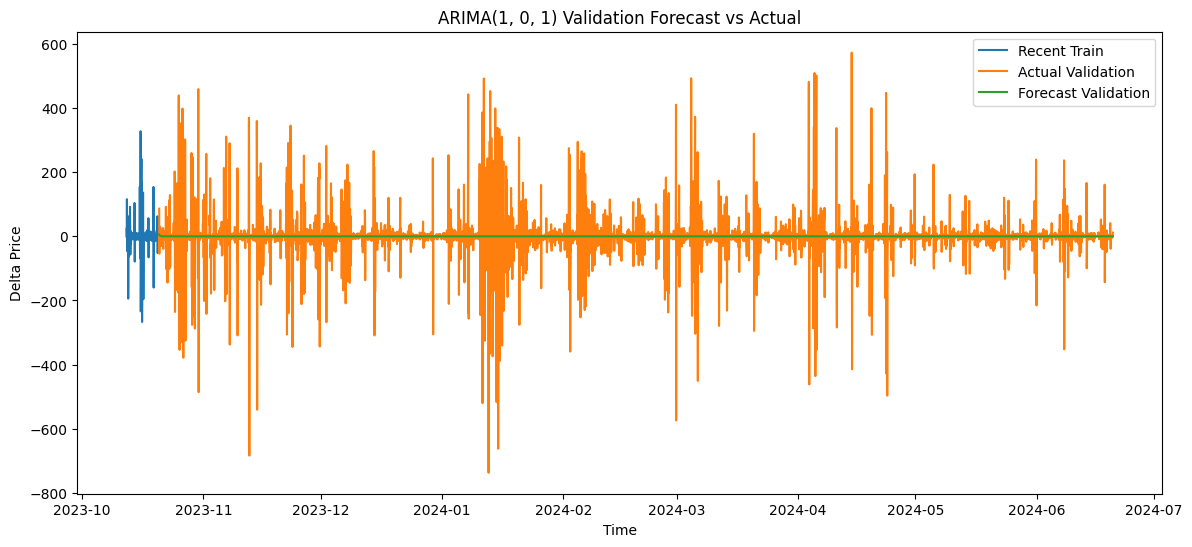

In [153]:
plt.figure(figsize=(14, 6))
plt.plot(train[-200:], label='Recent Train')
plt.plot(val, label='Actual Validation')
plt.plot(val_forecast, label='Forecast Validation')
plt.title(f'ARIMA{order} Validation Forecast vs Actual')
plt.xlabel('Time')
plt.ylabel('Delta Price')
plt.legend()
plt.show()

In [154]:
candidate_orders = [
    (1, 0, 0),
    (1, 0, 1),
    (2, 0, 0),
    (2, 0, 1),
    (1, 0, 2),
    (2, 0, 2)
]

results = []

for o in candidate_orders:
    try:
        model = ARIMA(train, order=o).fit()
        pred = model.forecast(steps=len(val))
        pred = pd.Series(pred.values, index=val.index)

        mae_o = mean_absolute_error(val, pred)
        rmse_o = np.sqrt(mean_squared_error(val, pred))
        mape_o = (np.abs((val - pred) / val.replace(0, np.nan))).mean() * 100

        results.append((o, mae_o, rmse_o, mape_o))
    except Exception as e:
        print(f"Order {o} failed: {e}")

results_df = pd.DataFrame(results, columns=['order', 'MAE', 'RMSE', 'MAPE']).sort_values('RMSE')
results_df

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/p

,order,MAE,RMSE,MAPE
3,"(2, 0, 1)",25.996191,65.964914,100.043825
5,"(2, 0, 2)",25.996113,65.964918,100.031173
4,"(1, 0, 2)",25.996397,65.964934,100.065681
1,"(1, 0, 1)",25.997197,65.965266,100.123590
0,"(1, 0, 0)",25.995909,65.965645,99.999453
2,"(2, 0, 0)",25.995859,65.965681,100.000786


In [155]:
best_order = results_df.iloc[0]['order']
print("Best ARIMA Order:", best_order)

Best ARIMA Order: (2, 0, 1)


In [156]:
final_arima = ARIMA(y, order=best_order).fit()
print(final_arima.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:            delta_price   No. Observations:                39009
Model:                 ARIMA(2, 0, 1)   Log Likelihood             -227029.335
Date:                Fri, 27 Mar 2026   AIC                         454068.670
Time:                        01:45:04   BIC                         454111.528
Sample:                             0   HQIC                        454082.252
                              - 39009                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0022      0.052     -0.042      0.966      -0.103       0.099
ar.L1          0.9062      0.003    343.488      0.000       0.901       0.911
ar.L2         -0.1113      0.002    -47.658      0.0

In [157]:
#Regularized Linear Benchmark
# Lasso Regression


from sklearn.linear_model import LassoCV, Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

In [158]:
# Check Dataframe

print("Data shape:", df.shape)
print("Date range:", df.index.min(), "to", df.index.max())
print(df.head())

Data shape: (39009, 30)
Date range: 2020-01-08 00:00:00 to 2024-06-20 13:00:00
                      T2M_AVG  WS50M_AVG   RH2M_AVG  GHI_AVG  price_lag_1  \
Date_Begin_Local                                                            
2020-01-08 00:00:00 -6.500000   9.153333  95.103333      0.0        27.15   
2020-01-08 01:00:00 -6.256667   9.803333  95.253333      0.0        27.25   
2020-01-08 02:00:00 -6.096667   9.913333  95.220000      0.0        26.63   
2020-01-08 03:00:00 -6.336667   9.323333  95.933333      0.0        25.41   
2020-01-08 04:00:00 -6.606667   9.123333  95.936667      0.0        26.93   

                     price_lag_24  price_lag_168  AIL_lag_1  AIL_lag_24  \
Date_Begin_Local                                                          
2020-01-08 00:00:00         34.48          30.24    10061.0      9932.0   
2020-01-08 01:00:00         32.97          29.43     9869.0      9827.0   
2020-01-08 02:00:00         35.64          29.66     9728.0      9773.0   
2020-0

In [159]:
# Define target and manual feature list

target_col = 'delta_price'

feature_cols = [
    'price_lag_1',
    'price_lag_24',
    'price_lag_168',
    'AIL_lag_1',
    'AIL_lag_24',
    'AIL_lag_168',
    'WS50M_AVG',
    'T2M_AVG',
    'RH2M_AVG',
    'hour_sin',
    'hour_cos',
    'dow_sin',
    'dow_cos',
    'month_sin',
    'month_cos',
    'is_cold_snap',
    'is_chinook',
    'is_low_wind',
    'is_high_wind'
]

print("Missing feature columns:", set(feature_cols) - set(df.columns))

Missing feature columns: {'AIL_lag_168'}


In [160]:
available_feature_cols = [col for col in feature_cols if col in df.columns]
missing_cols = [col for col in feature_cols if col not in df.columns]

print("Available columns:", available_feature_cols)
print("Missing columns:", missing_cols)

X = df[available_feature_cols].copy()
y = df[target_col].astype(float).copy()

print("X shape:", X.shape)
print("y shape:", y.shape)

Available columns: ['price_lag_1', 'price_lag_24', 'price_lag_168', 'AIL_lag_1', 'AIL_lag_24', 'WS50M_AVG', 'T2M_AVG', 'RH2M_AVG', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos', 'is_cold_snap', 'is_chinook', 'is_low_wind', 'is_high_wind']
Missing columns: ['AIL_lag_168']
X shape: (39009, 18)
y shape: (39009,)


In [162]:

# Adding non linear and interaction features

X['T2M_AVG_sq'] = X['T2M_AVG'] ** 2
X['WS50M_AVG_sq'] = X['WS50M_AVG'] ** 2
X['AIL_T2M_interaction'] = X['AIL_lag_1'] * X['T2M_AVG']
X['wind_coldsnap_interaction'] = X['WS50M_AVG'] * X['is_cold_snap']

print("Updated X shape with engineered features:", X.shape)

Updated X shape with engineered features: (39009, 22)


In [163]:
# Chronological train / validation split

split_ratio = 0.85
split_index = int(len(df) * split_ratio)

X_train = X.iloc[:split_index].copy()
X_val = X.iloc[split_index:].copy()

y_train = y.iloc[:split_index].copy()
y_val = y.iloc[split_index:].copy()

print("Training set shape:", X_train.shape, y_train.shape)
print("Validation set shape:", X_val.shape, y_val.shape)

print("Training period:", X_train.index.min(), "to", X_train.index.max())
print("Validation period:", X_val.index.min(), "to", X_val.index.max())

Training set shape: (33157, 22) (33157,)
Validation set shape: (5852, 22) (5852,)
Training period: 2020-01-08 00:00:00 to 2023-10-20 16:00:00
Validation period: 2023-10-20 17:00:00 to 2024-06-20 13:00:00


In [164]:
# Scale features
# Lasso requires standardized predictors

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

print("Scaled X_train shape:", X_train_scaled.shape)
print("Scaled X_val shape:", X_val_scaled.shape)

Scaled X_train shape: (33157, 22)
Scaled X_val shape: (5852, 22)


In [165]:
# Tune LASSO with Time series cross-validation

tscv = TimeSeriesSplit(n_splits=5)

lasso_cv = LassoCV(
    alphas=np.logspace(-6, 1, 80),
    cv=tscv,
    max_iter=30000,
    random_state=42
)

lasso_cv.fit(X_train_scaled, y_train)

best_alpha = lasso_cv.alpha_
print("Best alpha selected by LassoCV:", best_alpha)

Best alpha selected by LassoCV: 1e-06


In [166]:
# Fit final LASSO model

lasso_model = Lasso(alpha=best_alpha, max_iter=30000)
lasso_model.fit(X_train_scaled, y_train)

# Make validation predictions

lasso_val_pred = lasso_model.predict(X_val_scaled)

print("First 10 validation predictions:")
print(lasso_val_pred[:10])

First 10 validation predictions:
[  3.94579673 -18.3745792   -9.25268906  -7.8117399    0.68048054
   6.45161837   8.38794901  -0.76506991  -1.27292489  -8.50867193]


In [167]:
# Validation metrics

lasso_val_mae = mean_absolute_error(y_val, lasso_val_pred)
lasso_val_rmse = np.sqrt(mean_squared_error(y_val, lasso_val_pred))

def smape(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    denominator = (np.abs(y_true) + np.abs(y_pred)) / 2
    mask = denominator != 0
    return np.mean(np.abs(y_true[mask] - y_pred[mask]) / denominator[mask]) * 100

lasso_val_smape = smape(y_val, lasso_val_pred)

print("LASSO VALIDATION MAE:", lasso_val_mae)
print("LASSO VALIDATION RMSE:", lasso_val_rmse)
print("LASSO VALIDATION sMAPE:", lasso_val_smape)

LASSO VALIDATION MAE: 29.746138972534244
LASSO VALIDATION RMSE: 62.26998153400005
LASSO VALIDATION sMAPE: 145.8403140475823


In [168]:
# Results table

lasso_results = pd.DataFrame({
    'Model': ['Lasso Regression'],
    'Validation MAE': [lasso_val_mae],
    'Validation RMSE': [lasso_val_rmse],
    'Validation sMAPE': [lasso_val_smape],
    'Best Alpha': [best_alpha]
})

lasso_results

,Model,Validation MAE,Validation RMSE,Validation sMAPE,Best Alpha
0,Lasso Regression,29.746139,62.269982,145.840314,0.000001


In [169]:
# Coefficient Table
# Lasso shrinks some coefficients to zero

coef_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': lasso_model.coef_
})

coef_df['Abs_Coefficient'] = coef_df['Coefficient'].abs()
coef_df = coef_df.sort_values(by='Abs_Coefficient', ascending=False)

print("Top 20 Lasso coefficients:")
print(coef_df.head(20))

Top 20 Lasso coefficients:
                      Feature  Coefficient  Abs_Coefficient
6                     T2M_AVG   -78.108447        78.108447
20        AIL_T2M_interaction    74.224797        74.224797
0                 price_lag_1   -38.543223        38.543223
5                   WS50M_AVG   -35.404426        35.404426
19               WS50M_AVG_sq    28.157047        28.157047
1                price_lag_24    14.403013        14.403013
18                 T2M_AVG_sq    10.222189        10.222189
9                    hour_cos    -7.024134         7.024134
2               price_lag_168     5.937077         5.937077
13                  month_cos     5.108998         5.108998
3                   AIL_lag_1    -3.975305         3.975305
14               is_cold_snap     3.466984         3.466984
21  wind_coldsnap_interaction    -3.099202         3.099202
10                    dow_sin     2.606156         2.606156
4                  AIL_lag_24    -1.909884         1.909884
17           

In [170]:
# Count selected and removed features

non_zero_coefs = (coef_df['Coefficient'] != 0).sum()
zero_coefs = (coef_df['Coefficient'] == 0).sum()

print("Number of selected features (non-zero coefficients):", non_zero_coefs)
print("Number of removed features (zero coefficients):", zero_coefs)

Number of selected features (non-zero coefficients): 22
Number of removed features (zero coefficients): 0


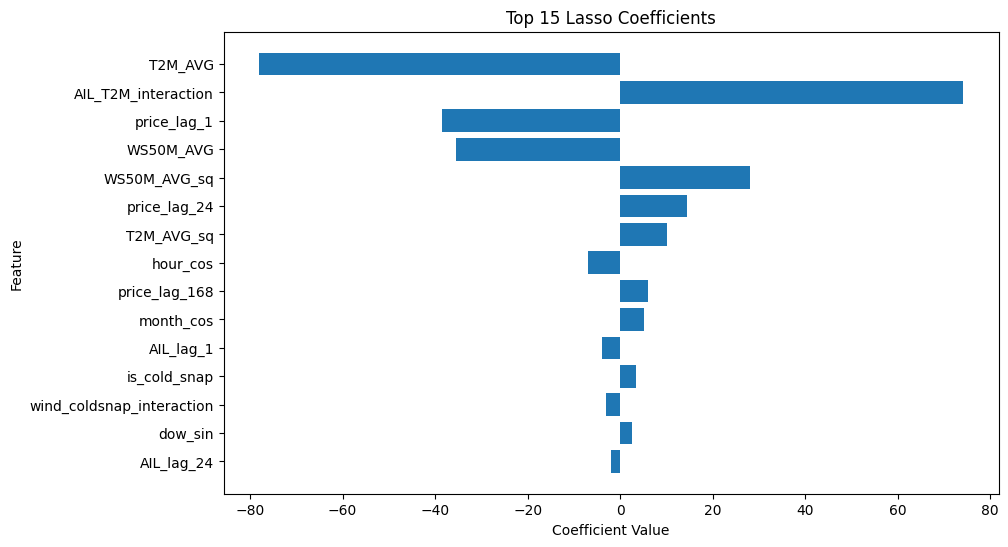

In [171]:
# Plot top 15 Coefficients

top_15 = coef_df.head(15)

plt.figure(figsize=(10, 6))
plt.barh(top_15['Feature'], top_15['Coefficient'])
plt.title('Top 15 Lasso Coefficients')
plt.xlabel('Coefficient Value')
plt.ylabel('Feature')
plt.gca().invert_yaxis()
plt.show()

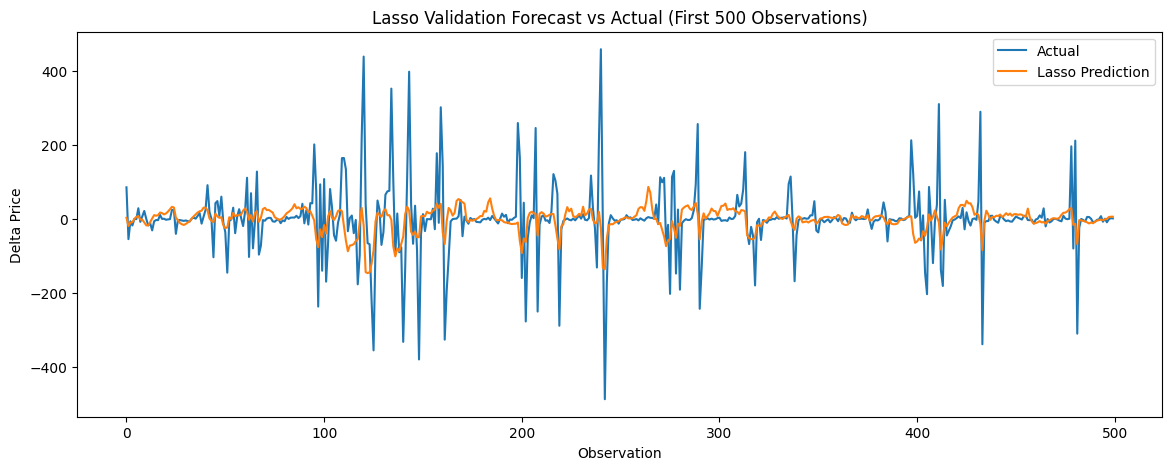

In [172]:
# Plot actual VS predicted on validation set

plt.figure(figsize=(14, 5))
plt.plot(y_val.iloc[:500].values, label='Actual')
plt.plot(lasso_val_pred[:500], label='Lasso Prediction')
plt.title('Lasso Validation Forecast vs Actual (First 500 Observations)')
plt.xlabel('Observation')
plt.ylabel('Delta Price')
plt.legend()
plt.show()

In [173]:
# Validation output

lasso_validation_output = pd.DataFrame({
    'Actual': y_val.values,
    'Lasso_Prediction': lasso_val_pred
}, index=y_val.index)

lasso_validation_output.head()

,Actual,Lasso_Prediction
Date_Begin_Local,,
2023-10-20 17:00:00,86.19,3.945797
2023-10-20 18:00:00,-53.85,-18.374579
2023-10-20 19:00:00,-5.54,-9.252689
2023-10-20 20:00:00,-16.97,-7.811740
2023-10-20 21:00:00,0.86,0.680481
